# Results Synthesis and Defense Pack

## Objective
This final notebook gathers the main outputs into a dissertation-ready pack. The emphasis is on organisation: which figures and tables belong in the written report, which claims are defendable, and which caveats need to appear wherever synthetic fusion is discussed.


In [1]:
from __future__ import annotations

import json
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')

CWD = Path.cwd().resolve()
if (CWD / 'src').exists() and (CWD / 'data').exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / 'src').exists() and (CWD.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent
elif (CWD.parent.parent / 'src').exists() and (CWD.parent.parent / 'data').exists():
    PROJECT_ROOT = CWD.parent.parent
else:
    raise RuntimeError(f'Could not resolve dissertation_project root from {CWD}')

REPO_ROOT = PROJECT_ROOT.parent
OUTPUTS = PROJECT_ROOT / 'outputs_v2'
FIGURES = OUTPUTS / 'figures'
METRICS = OUTPUTS / 'metrics'
REPORTS = OUTPUTS / 'reports'
MODELS = PROJECT_ROOT / 'models'
DATA_ROOT = PROJECT_ROOT / 'data' / 'dataset_cancer_v1' / 'dataset_cancer_v1'
WISCONSIN_ROOT = PROJECT_ROOT / 'notebook_Wisconsin'

for path in [FIGURES, METRICS, REPORTS]:
    path.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print('Project root:', PROJECT_ROOT)
print('Outputs:', OUTPUTS)

from IPython.display import Image, display

key_tables = {
    'breakhis_patient_metrics': pd.read_csv(METRICS / 'breakhis_patient_level_metrics.csv'),
    'fusion_summary': pd.read_csv(METRICS / 'synthetic_fusion_summary.csv'),
    'joint_comparison': pd.read_csv(METRICS / 'joint_model_comparison.csv'),
}
for name, frame in key_tables.items():
    print(f'\n{name}')
    display(frame.head(10))


Project root: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project
Outputs: /Users/sergeysotskiy/Documents/UNI/year 3/Dissertation/dissertation_project/outputs_v2

breakhis_patient_metrics


,accuracy,precision,recall,f1_score,roc_auc,brier_score,ece
0,0.769231,0.8,0.888889,0.842105,0.916667,0.117235,0.230616



fusion_summary


,pairing_type,experiment,metric,mean,std,min,max
0,random,early_fusion,accuracy,0.971930,0.020003,0.938596,0.991228
1,random,early_fusion,brier_score,0.023558,0.013549,0.009933,0.043916
2,random,early_fusion,f1_score,0.961503,0.027512,0.915663,0.987952
3,random,early_fusion,precision,0.970848,0.026746,0.926829,1.000000
4,random,early_fusion,recall,0.952381,0.029161,0.904762,0.976190
5,random,early_fusion,roc_auc,0.991799,0.010191,0.976852,0.999339
6,random,image_only,accuracy,0.582456,0.045833,0.508772,0.622807
7,random,image_only,brier_score,0.282536,0.027133,0.260963,0.326793
8,random,image_only,f1_score,0.341367,0.079527,0.222222,0.441558
9,random,image_only,precision,0.406467,0.086647,0.266667,0.485714



joint_comparison


,family,model,accuracy,roc_auc,calibration_or_stability,claim_type
0,monomodel,BreaKHis corrected patient-level model,0.769231,0.916667,ECE=0.231,new defendable image result
1,monomodel,Wisconsin published branch,0.960000,0.997000,MC Dropout reported in source notebook,published frozen branch
2,synthetic_fusion,random | early_fusion,0.971930,0.991799,std_acc=0.020,exploratory only
3,synthetic_fusion,random | late_fusion,0.977193,0.987500,std_acc=0.008,exploratory only
4,synthetic_fusion,same_label | early_fusion,0.998246,1.000000,std_acc=0.004,exploratory only


In [2]:
defense_claims = pd.DataFrame(
    [
        {'claim_type': 'Defendable', 'statement': 'Patient-level splitting is necessary on BreaKHis because image-level splitting leaks patients across subsets.'},
        {'claim_type': 'Defendable', 'statement': 'The corrected BreaKHis result is lower than the earlier leaked result but substantially more trustworthy.'},
        {'claim_type': 'Defendable', 'statement': 'The Wisconsin branch is a frozen published comparator rather than newly re-optimised work.'},
        {'claim_type': 'Exploratory only', 'statement': 'Synthetic same-label fusion can improve metrics, but those gains may reflect artificial label alignment rather than genuine multimodal complementarity.'},
        {'claim_type': 'Exploratory only', 'statement': 'Random-pairing controls are essential for interpreting synthetic multimodal experiments.'},
    ]
)
defense_claims.to_csv(REPORTS / 'defense_claims.csv', index=False)
defense_claims


,claim_type,statement
0,Defendable,Patient-level splitting is necessary on BreaKH...
1,Defendable,The corrected BreaKHis result is lower than th...
2,Defendable,The Wisconsin branch is a frozen published com...
3,Exploratory only,Synthetic same-label fusion can improve metric...
4,Exploratory only,Random-pairing controls are essential for inte...


In [3]:
figure_manifest = pd.DataFrame(
    [
        {'figure_path': str(FIGURES / 'breakhis_sample_mosaic.png'), 'suggested_use': 'Dataset chapter or exploratory analysis section'},
        {'figure_path': str(FIGURES / 'breakhis_leakage_audit.png'), 'suggested_use': 'Methods chapter to justify patient-level splitting'},
        {'figure_path': str(FIGURES / 'breakhis_model_development_comparison.png'), 'suggested_use': 'Model development section'},
        {'figure_path': str(FIGURES / 'breakhis_patient_confusion_matrix.png'), 'suggested_use': 'Results chapter'},
        {'figure_path': str(FIGURES / 'breakhis_patient_roc_curve.png'), 'suggested_use': 'Results chapter'},
        {'figure_path': str(FIGURES / 'breakhis_patient_calibration.png'), 'suggested_use': 'Results or discussion chapter'},
        {'figure_path': str(FIGURES / 'fusion_experiment_comparison.png'), 'suggested_use': 'Exploratory fusion section'},
        {'figure_path': str(FIGURES / 'joint_model_accuracy_comparison.png'), 'suggested_use': 'Comparison/discussion chapter'},
    ]
)
figure_manifest.to_csv(REPORTS / 'figure_manifest.csv', index=False)
figure_manifest


,figure_path,suggested_use
0,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,Dataset chapter or exploratory analysis section
1,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,Methods chapter to justify patient-level split...
2,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,Model development section
3,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,Results chapter
4,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,Results chapter
5,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,Results or discussion chapter
6,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,Exploratory fusion section
7,/Users/sergeysotskiy/Documents/UNI/year 3/Diss...,Comparison/discussion chapter



Showing breakhis_leakage_audit.png


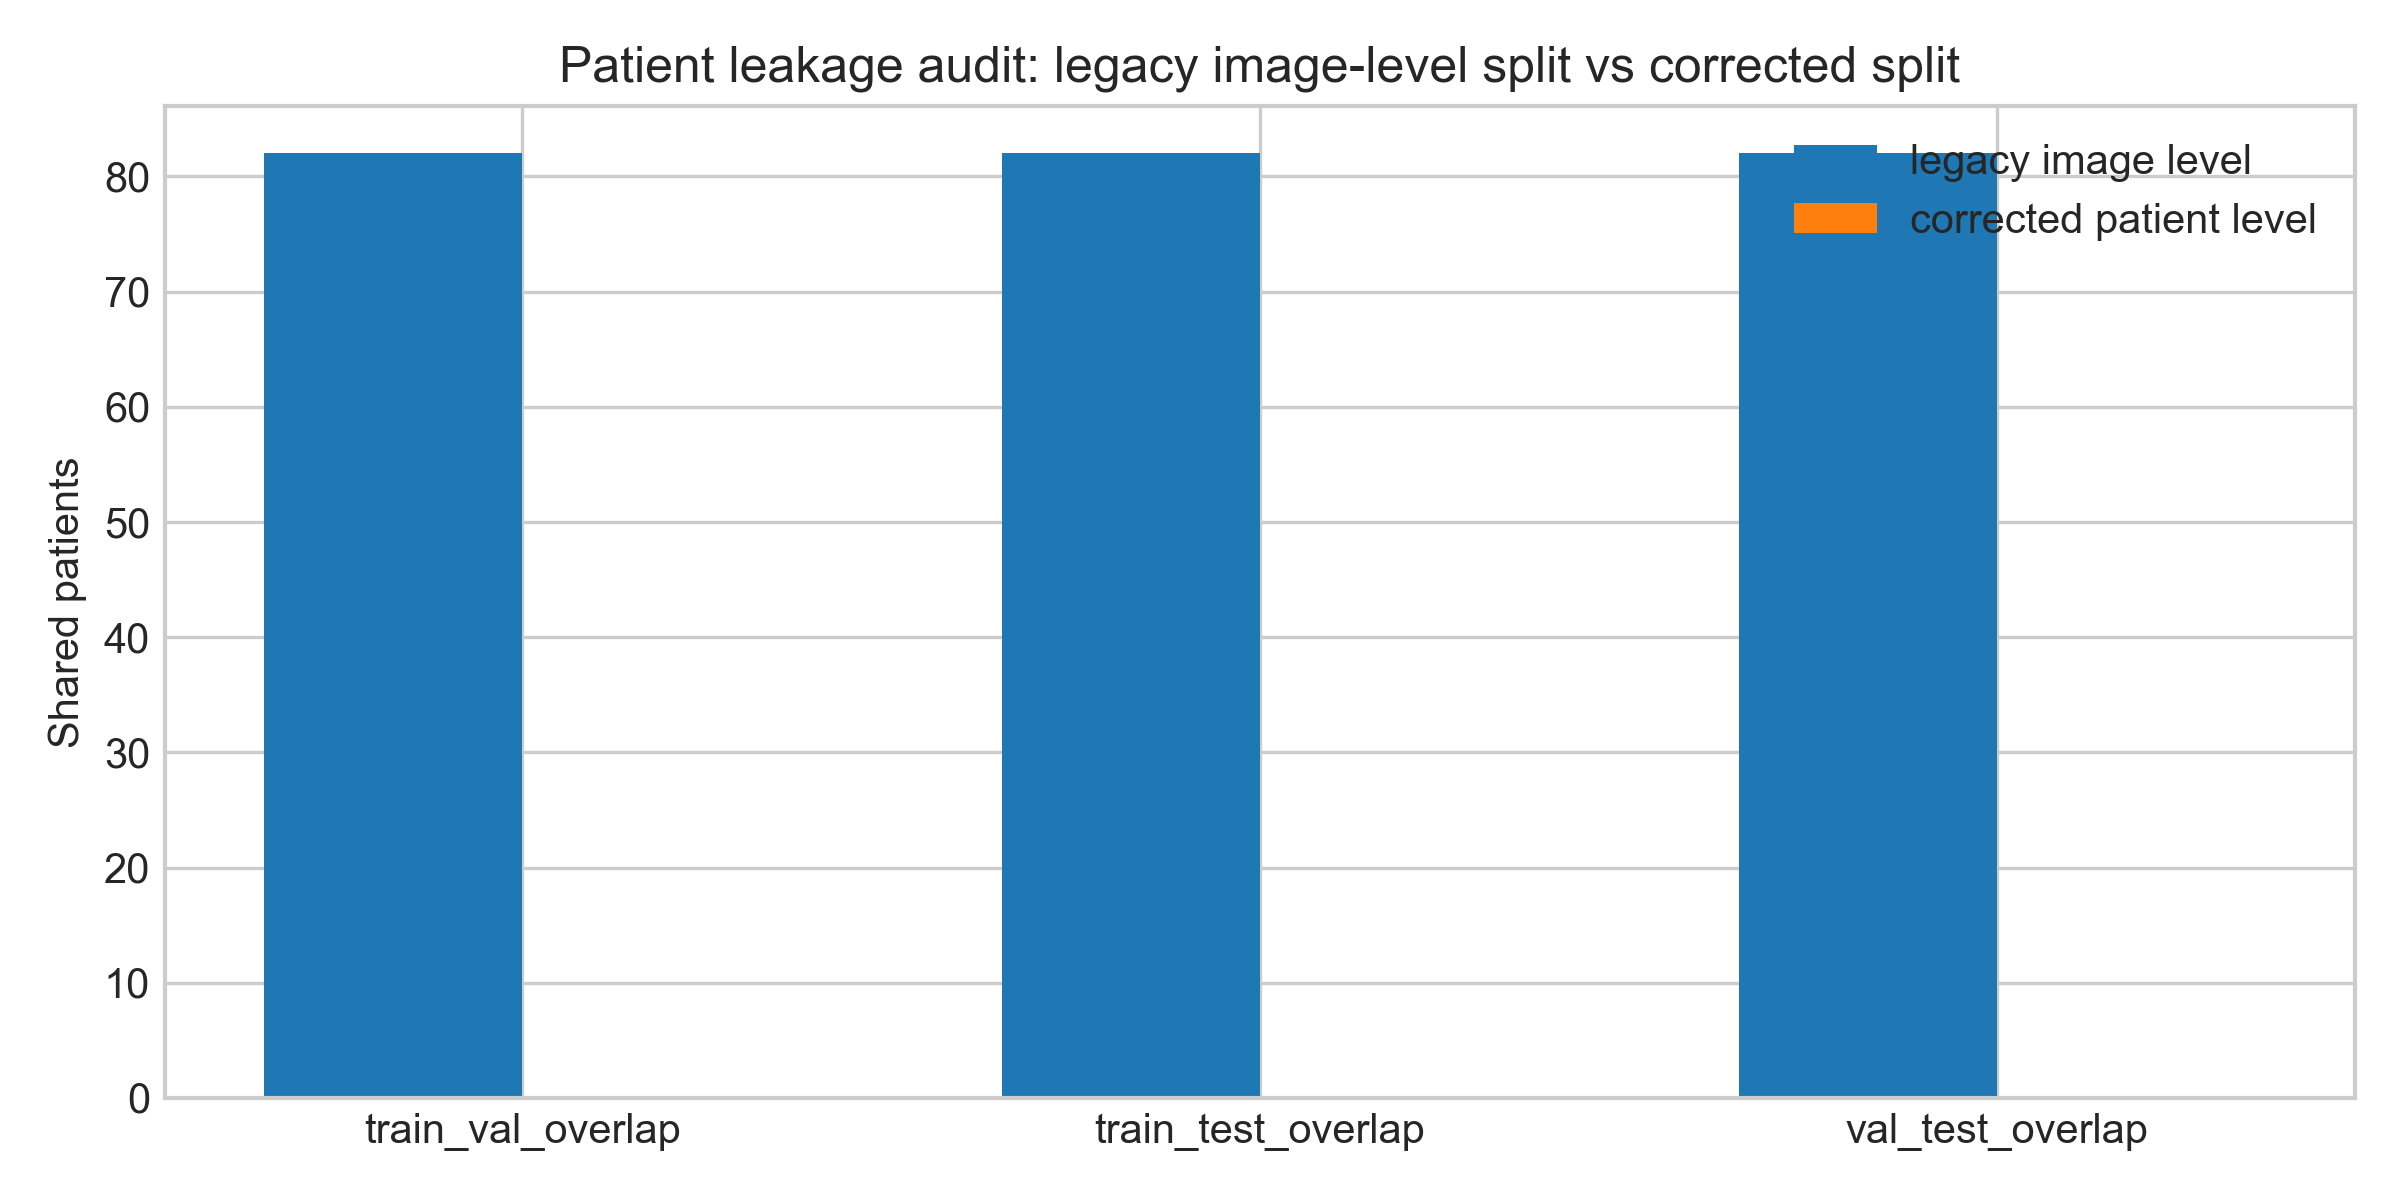


Showing breakhis_patient_confusion_matrix.png


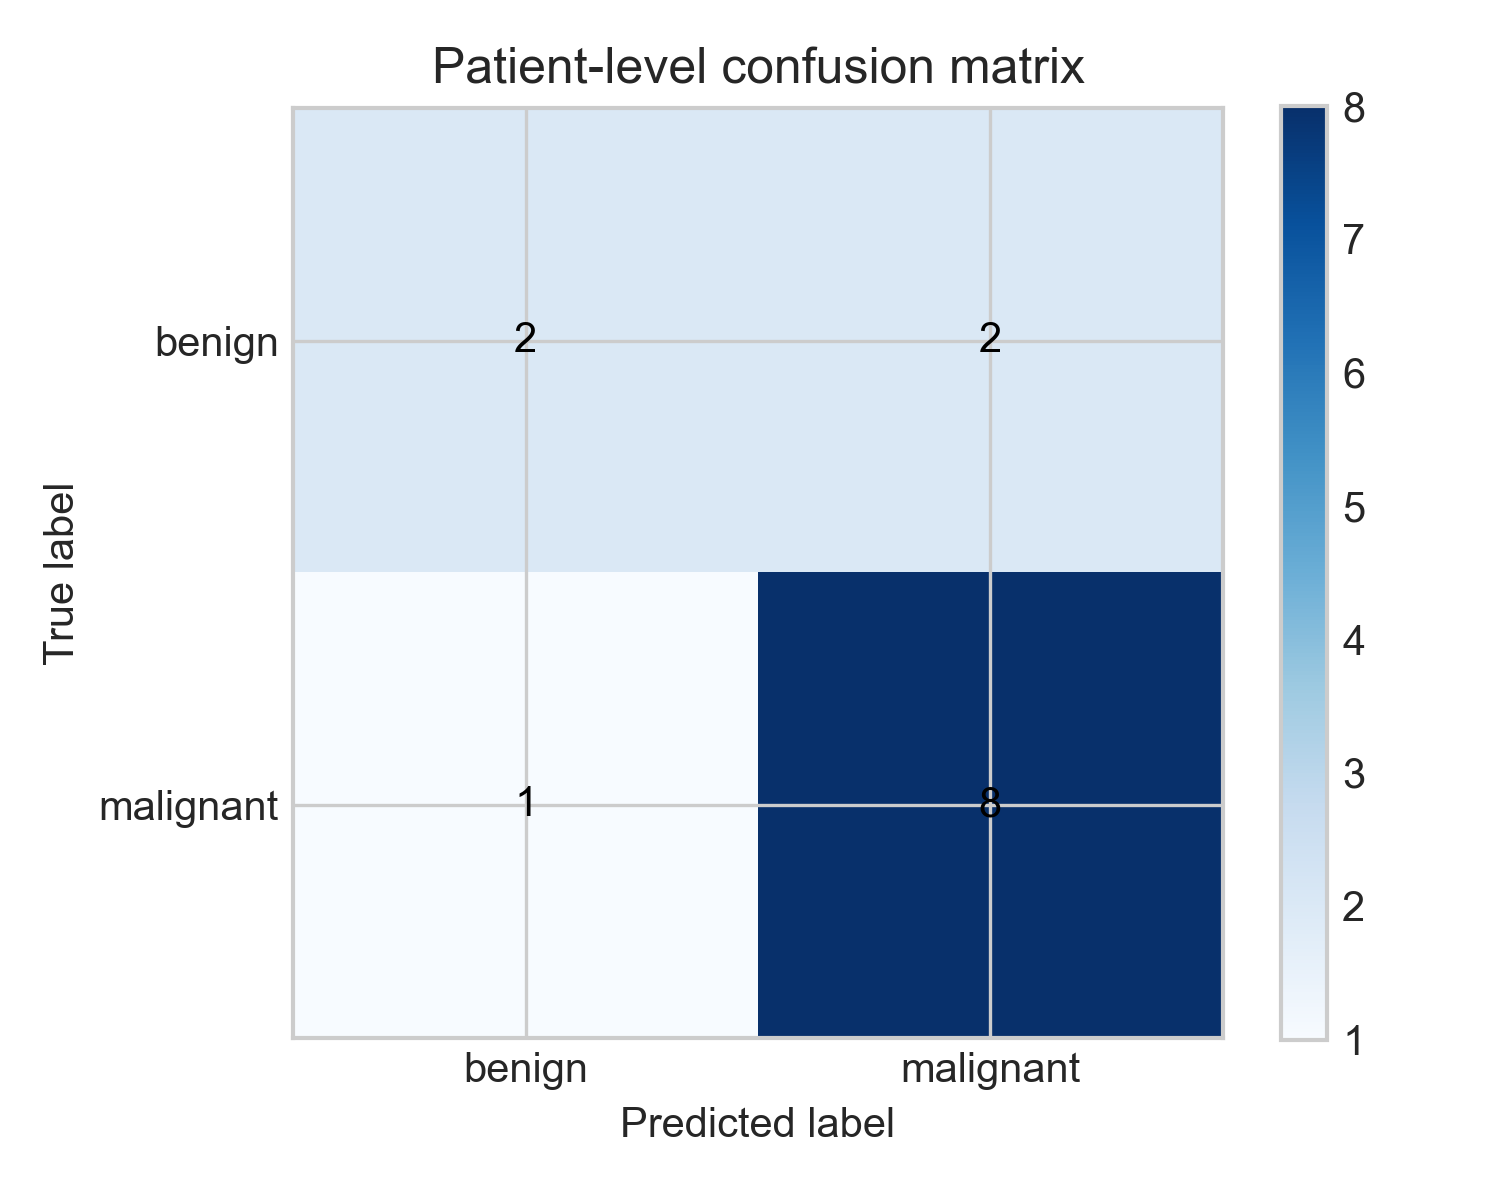


Showing fusion_experiment_comparison.png


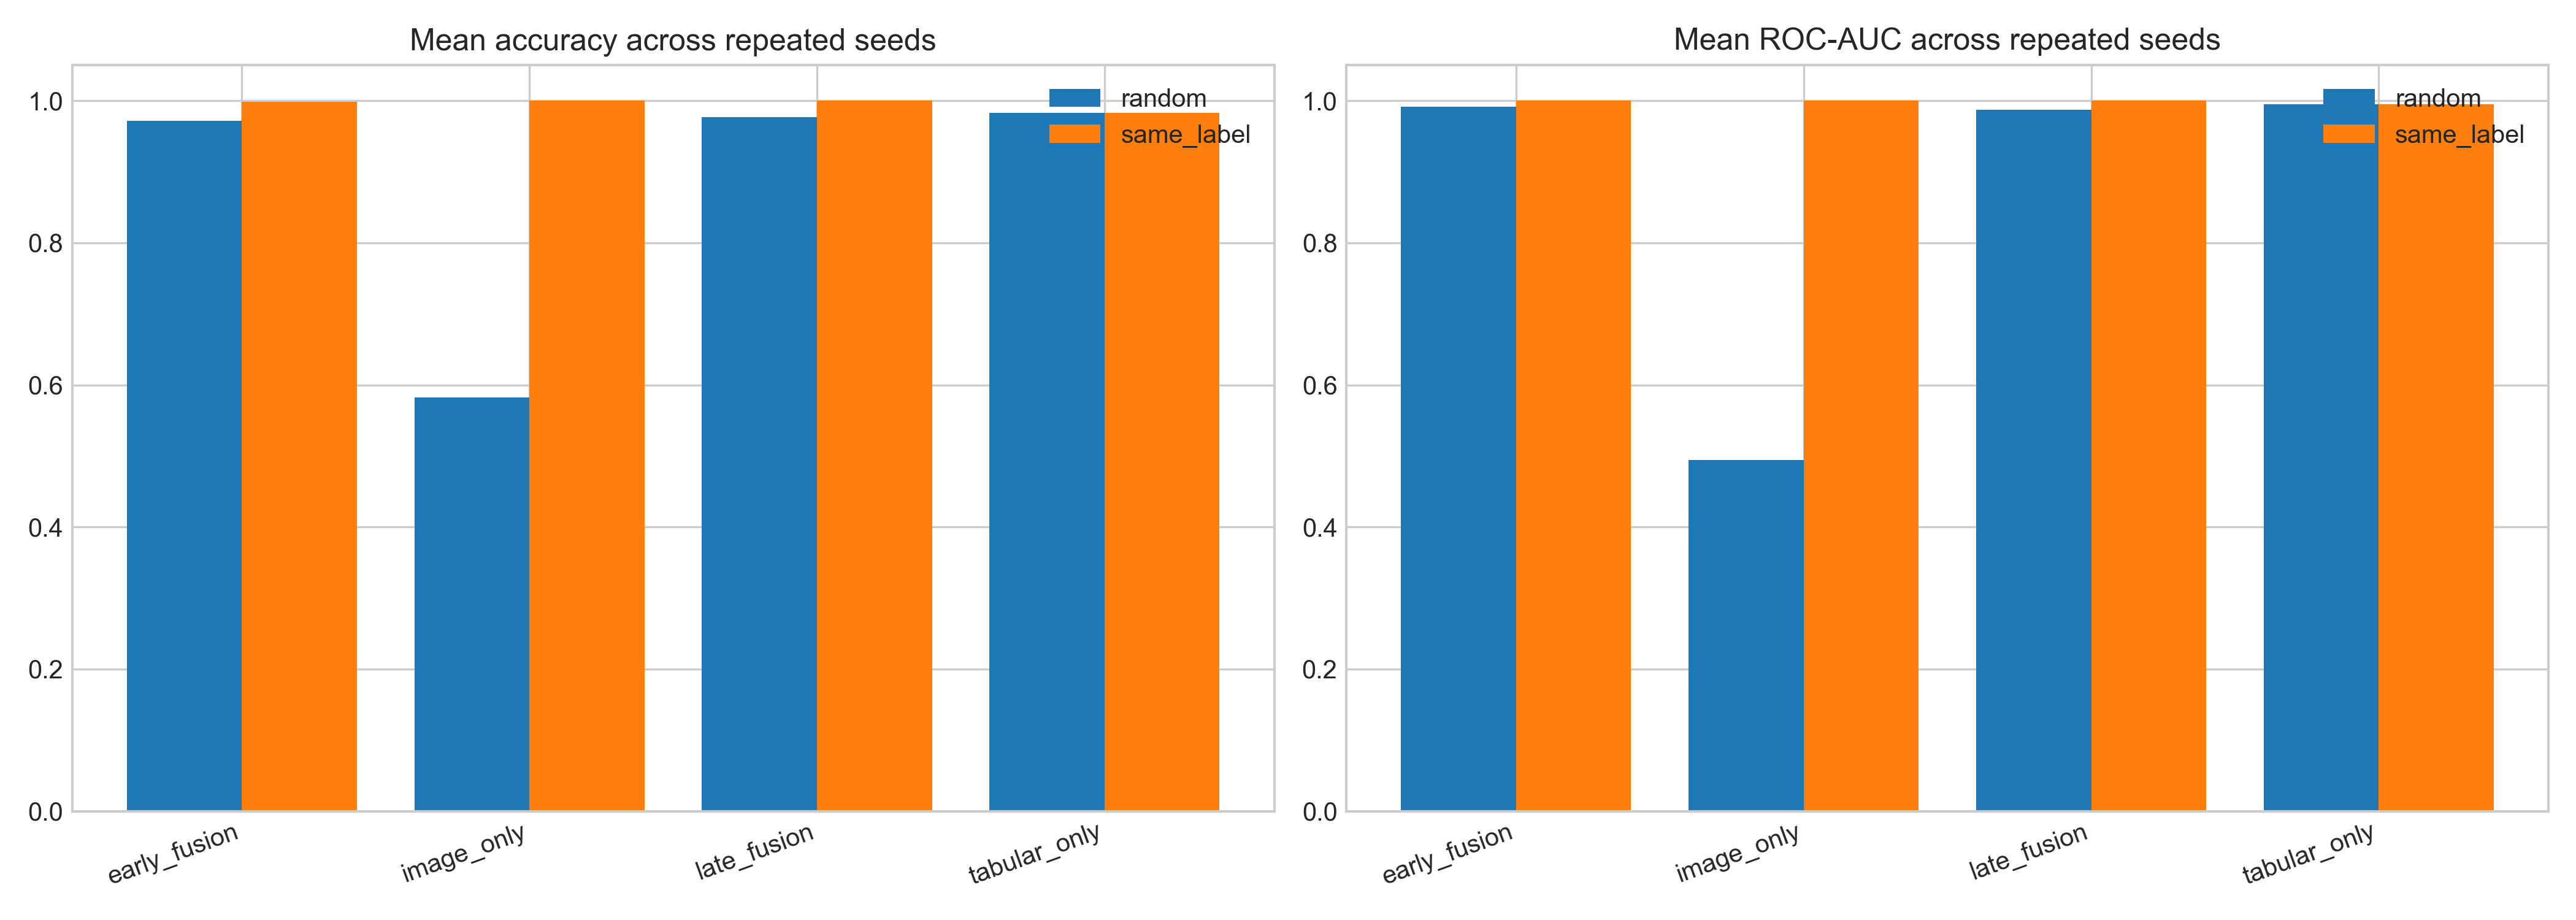


Showing joint_model_accuracy_comparison.png


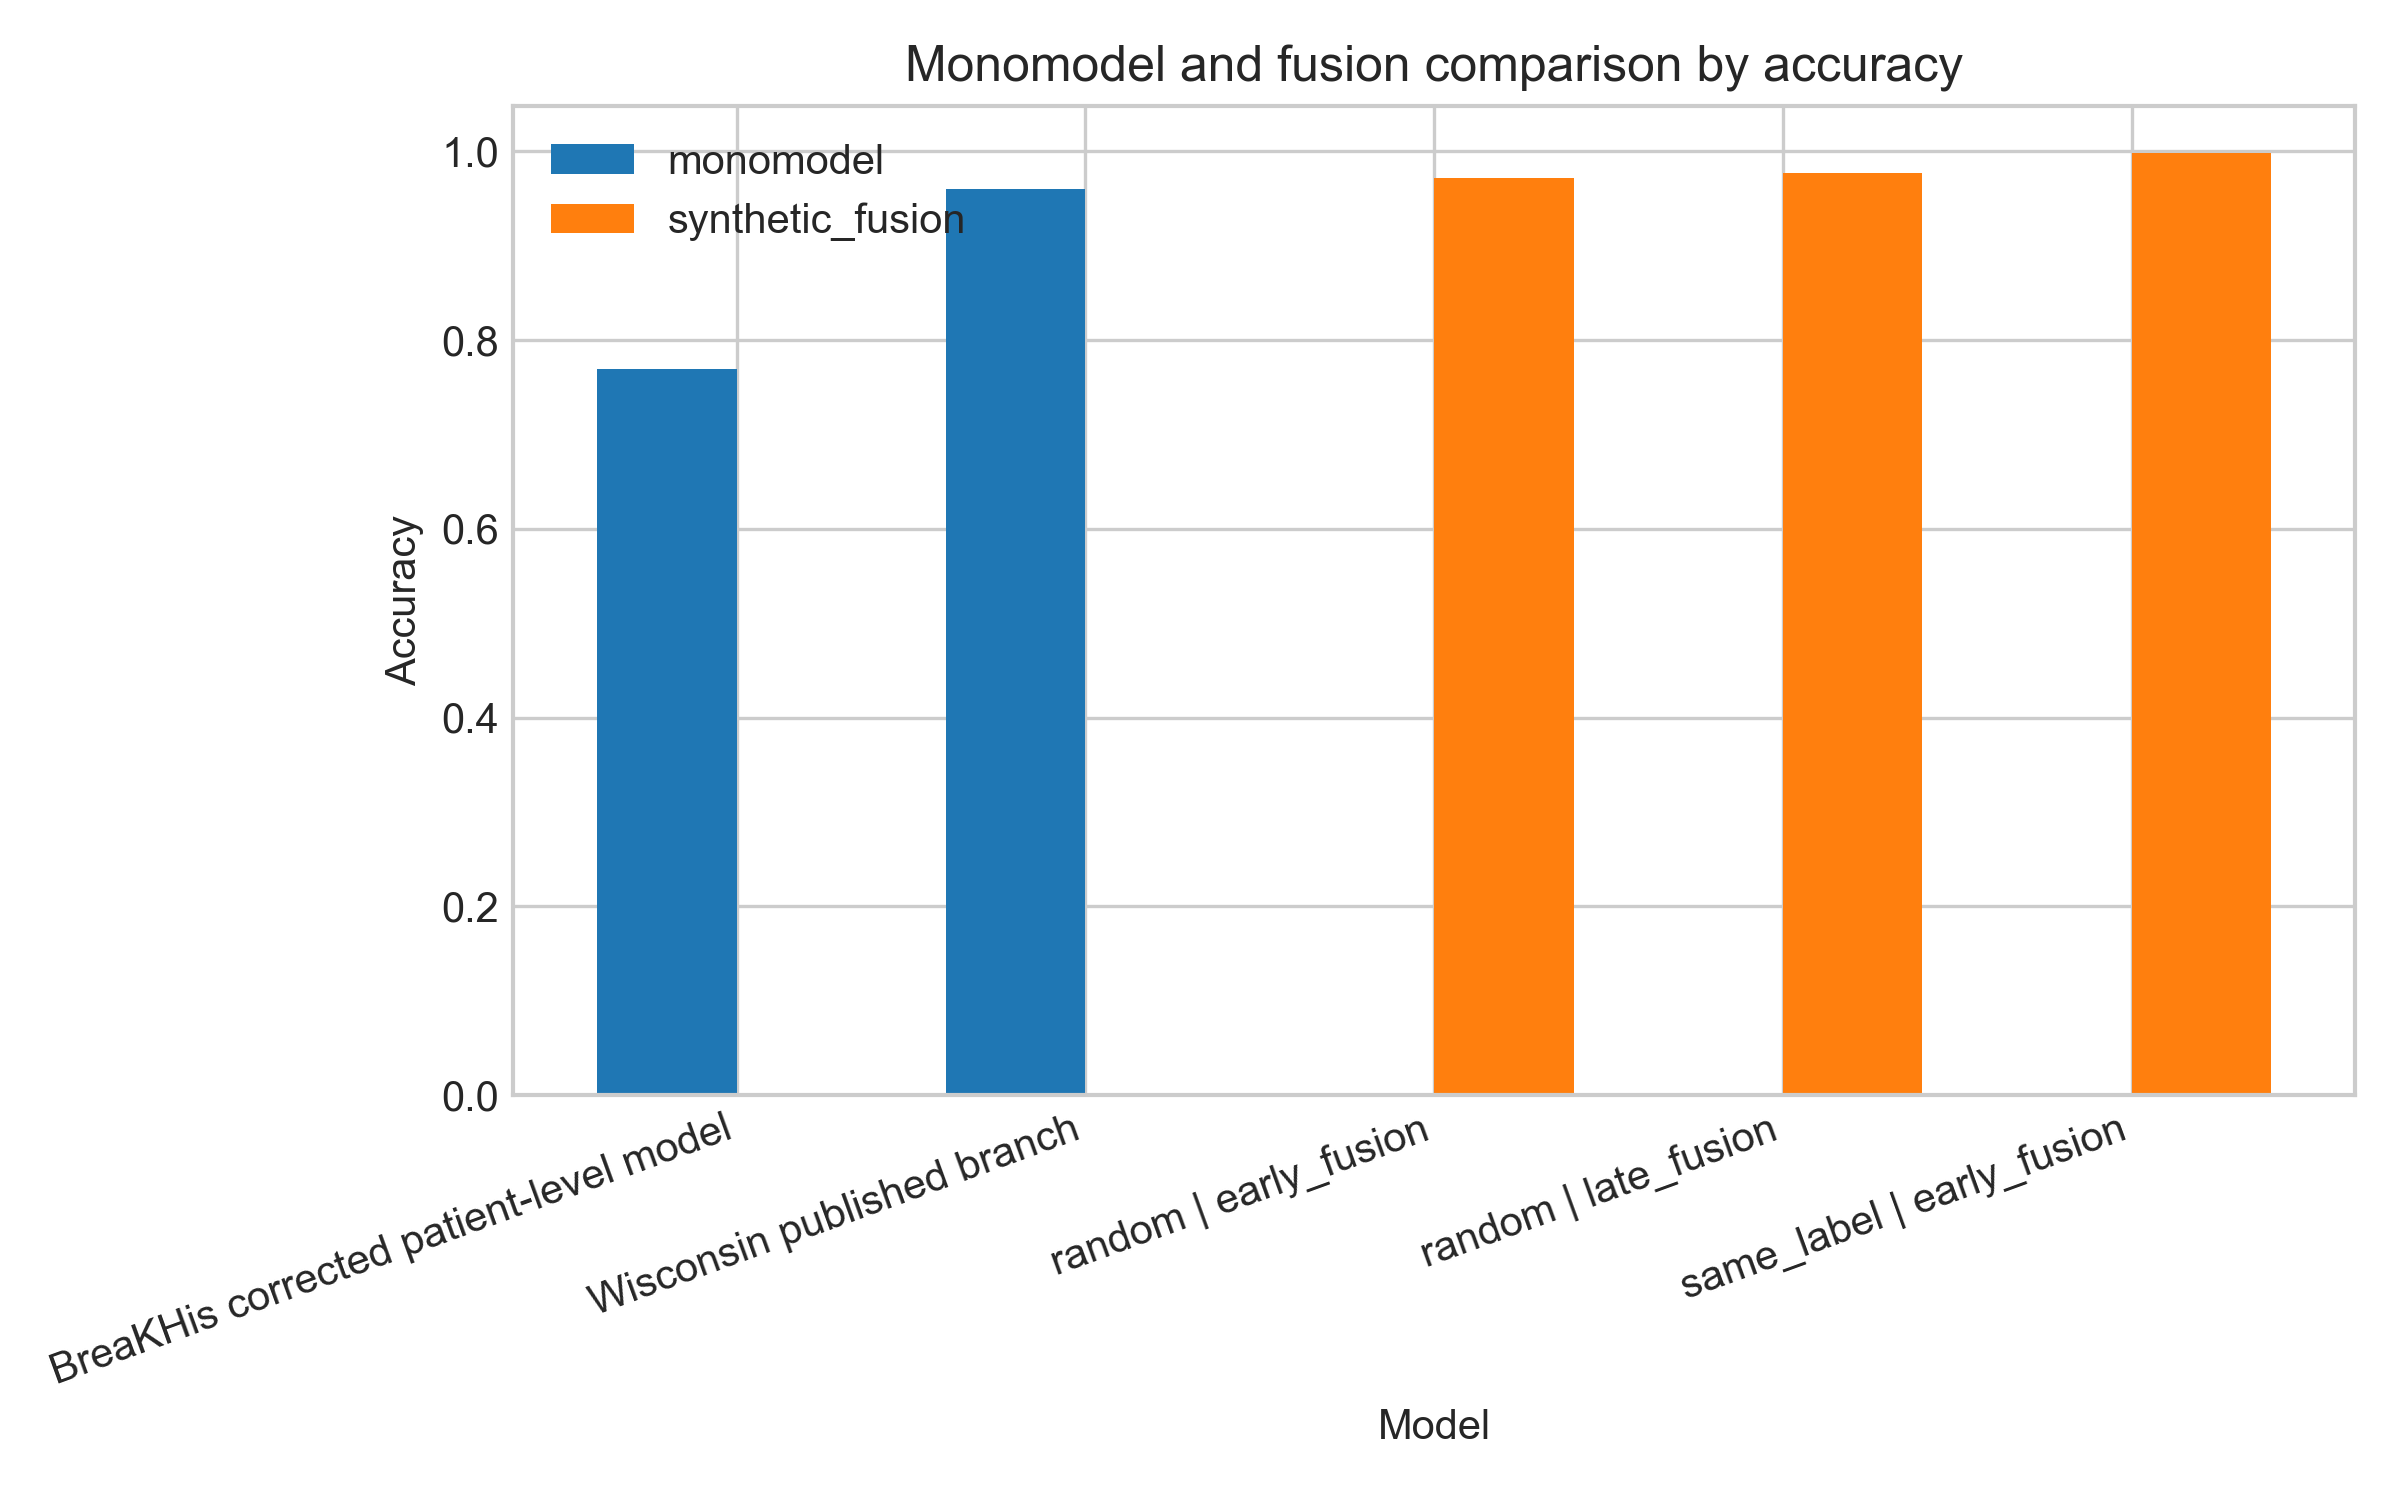

In [4]:
for figure_name in [
    'breakhis_leakage_audit.png',
    'breakhis_patient_confusion_matrix.png',
    'fusion_experiment_comparison.png',
    'joint_model_accuracy_comparison.png',
]:
    print('\nShowing', figure_name)
    display(Image(filename=str(FIGURES / figure_name)))


## Final Position

The dissertation can now be written around a clear narrative.

- **New defensible contribution:** the corrected patient-level BreaKHis analysis and its error/calibration discussion.
- **Frozen comparator:** the Wisconsin monomodel branch from prior work.
- **Exploratory extension:** synthetic multimodal pairing with explicit random controls.

This structure is much stronger than claiming a clinically valid multimodal model without matched data.
